In [404]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score
)

In [405]:
df = pd.read_csv("C:/Users/shami/Downloads/archive (1)/student_exam_performance_dataset.csv")

In [406]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [407]:
df = df.drop(['previous_gpa','pass_fail','grade_category','student_id'],axis = 1)

In [408]:
df = pd.get_dummies(df,columns = ['gender','parental_education','family_income','internet_access','study_environment','tutoring'])

In [409]:
scaler = StandardScaler()
# df = df / np.linalg.norm(df)
df = pd.DataFrame(scaler.fit_transform(df),columns = df.columns,index = df.index)
print(type(df))
df.head()

<class 'pandas.core.frame.DataFrame'>


,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,...,family_income_High,family_income_Low,family_income_Medium,internet_access_No,internet_access_Yes,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet,tutoring_No,tutoring_Yes
0,0.457028,-0.033669,1.240568,-0.977038,-1.670932,0.073282,-0.076188,-0.716098,-0.483008,0.946513,...,-0.493899,-0.650137,0.986491,-0.33592,0.33592,-0.807511,-0.496873,1.206314,-1.528981,1.528981
1,1.347748,1.212964,1.156434,-0.059389,0.264537,-0.624263,1.554261,-1.411812,2.046091,1.777417,...,-0.493899,1.538139,-1.013694,-0.33592,0.33592,-0.807511,-0.496873,1.206314,-1.528981,1.528981
2,0.457028,0.619329,-0.915345,0.001115,-0.081082,-0.137435,-1.638418,1.371043,0.287971,-0.857523,...,-0.493899,-0.650137,0.986491,2.97690,-2.97690,-0.807511,-0.496873,1.206314,-1.528981,1.528981
3,1.347748,-0.839317,-1.272911,-0.795525,0.679280,-1.161954,0.210334,1.371043,-1.527792,-1.965396,...,-0.493899,-0.650137,0.986491,-0.33592,0.33592,-0.807511,-0.496873,1.206314,0.654030,-0.654030
4,1.347748,1.798118,0.273036,1.533892,-0.288454,-0.558868,-0.963044,-1.411812,1.815517,0.385091,...,-0.493899,-0.650137,0.986491,-0.33592,0.33592,-0.807511,-0.496873,1.206314,0.654030,-0.654030


In [410]:
X = df.drop(['final_exam_score'],axis = 1)
print(X,'\n',X.shape)

           age  study_hours_per_day  attendance_rate  sleep_hours  \
0     0.457028            -0.033669         1.240568    -0.977038   
1     1.347748             1.212964         1.156434    -0.059389   
2     0.457028             0.619329        -0.915345     0.001115   
3     1.347748            -0.839317        -1.272911    -0.795525   
4     1.347748             1.798118         0.273036     1.533892   
...        ...                  ...              ...          ...   
9995 -1.324411             0.661732        -0.168663     0.464982   
9996 -1.324411            -0.474655        -1.756676    -0.261070   
9997 -1.324411             1.747235        -0.915345    -0.119893   
9998  1.347748            -1.237900         0.662152     0.112040   
9999  0.457028             0.517563         1.608650    -1.612334   

      social_media_hours  assignment_completion_rate  participation_score  \
0              -1.670932                    0.073282            -0.076188   
1               0

In [411]:
Y = df['final_exam_score']
print(Y,'\n',Y.shape)

0      -0.047897
1       1.680610
2      -0.615835
3      -1.463626
4       1.376063
          ...   
9995   -0.640528
9996   -0.179593
9997    1.194982
9998   -0.442984
9999    0.816356
Name: final_exam_score, Length: 10000, dtype: float64 
 (10000,)


In [412]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 0
)

In [413]:
n,m = X_train.shape[1],X_train.shape[0]
print(n,m)

28 8000


In [414]:
X_train = X_train.to_numpy().T
print(X_train.shape)
X_test = X_test.to_numpy().T
print(X_test.shape)
Y_train = Y_train.to_numpy().reshape(1,m)
Y_test = Y_test.to_numpy().reshape(1,2000)
print(Y_train.shape)
print(Y_test.shape)

(28, 8000)
(28, 2000)
(1, 8000)
(1, 2000)


In [415]:
w = np.zeros((n,1))
b = 0
a = 0.01
losses = []

In [416]:
for i in range(1000):
    Z = np.dot(w.T,X_train) + b
    dz = Z - Y_train
    J = 1/(2*m) * np.sum(dz**2)
    losses.append(J)
    dw = 1/m * np.dot(X_train,dz.T)
    db = 1/m * np.sum(dz)
    w -= a * dw
    b -= a * db
print("w =",w)
print("b =",b)

w = [[ 1.03808294e-03]
 [ 1.98672943e-03]
 [-5.24156884e-04]
 [ 1.21106524e-03]
 [-1.73654214e-03]
 [ 2.59665229e-03]
 [-1.56947108e-04]
 [-5.78637412e-05]
 [ 2.86853898e-01]
 [ 2.72351452e-01]
 [ 2.73361703e-01]
 [ 2.84823553e-01]
 [ 5.71891158e-04]
 [-5.71891158e-04]
 [ 3.33694380e-03]
 [-2.49105804e-03]
 [-1.31982922e-03]
 [ 7.04617965e-04]
 [-2.54318599e-03]
 [ 2.74289720e-03]
 [-4.87429686e-04]
 [ 1.16935367e-03]
 [-1.16935367e-03]
 [-1.26099565e-03]
 [-1.44752423e-03]
 [ 2.42847062e-03]
 [ 7.65060119e-04]
 [-7.65060119e-04]]
b = 0.0011664683743118336


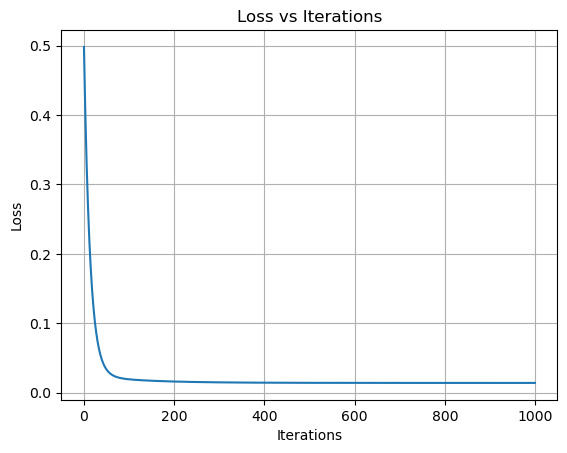

In [417]:
plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")

plt.grid(True)

plt.show()

In [418]:
Y_pred = np.dot(w.T,X_test) + b

In [419]:
Y_pred = Y_pred.flatten()
Y_test = Y_test.flatten()

In [420]:
mse = mean_squared_error(Y_test, Y_pred)
print("MSE =", mse)

MSE = 0.025750208672764743


In [421]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
print("RMSE =", rmse)

RMSE = 0.16046871555778325


In [422]:
mae = mean_absolute_error(Y_test, Y_pred)
print("MAE =", mae)

MAE = 0.12781928220603236


In [423]:
r2 = r2_score(Y_test, Y_pred)
print("R² Score =", r2)

R² Score = 0.9745917432515698


In [424]:
mape = mean_absolute_percentage_error(Y_test, Y_pred)
print("MAPE =", mape * 100, "%")

MAPE = 91.73169498279961 %


In [425]:
evs = explained_variance_score(Y_test, Y_pred)
print("Explained Variance Score =", evs)

Explained Variance Score = 0.9746252112158202


In [426]:
accuracy = (1 - np.mean(np.abs((Y_test - Y_pred)/Y_test))) * 100
print("Accuracy =", accuracy, "%")

Accuracy = 8.268305017200394 %


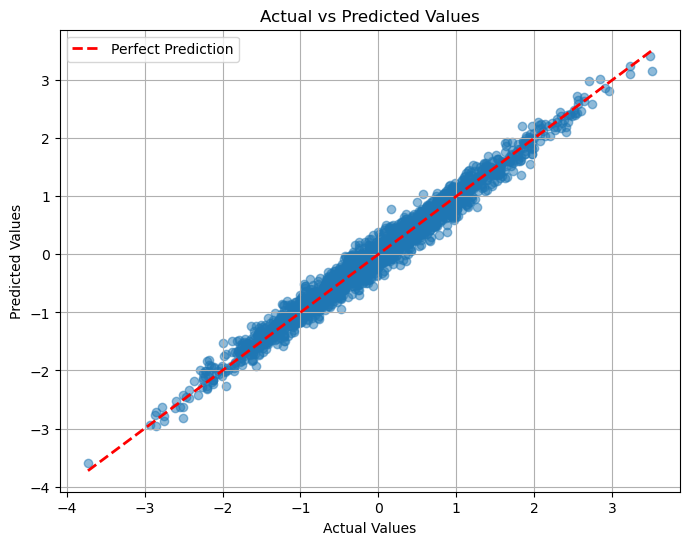

In [427]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, Y_pred, alpha=0.5)

min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--',
         linewidth=2,
         label='Perfect Prediction')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.grid(True)

plt.show()